# Fase 1: modelo predictivo de la calificación de películas

Proyecto integrador de Modelos y Simulación de Sistemas I (Universidad de Antioquia).
Equipo: Alejandro Múnera Ramírez, Miguel Ángel Altamiranda y Juan Esteban González Duque.

**Objetivo.** Construir un modelo de regresión que prediga `vote_average` (calificación promedio de los usuarios de TMDB, escala 0 a 10) usando solo características que se conocen antes o al momento del estreno de una película.

**Dataset.** The Movies Dataset (Rounak Banik, Kaggle), archivo `movies_metadata.csv`. El README del repositorio explica cómo descargarlo y dónde ubicarlo (`data/movies_metadata.csv`).

**Estructura del notebook.**

1. Carga de datos
2. Limpieza: filas corruptas y películas duplicadas
3. Análisis exploratorio (EDA)
4. Preparación de variables y fuga de información
5. División train/test y Pipeline de preprocesamiento
6. Modelos y evaluación
7. Guardado del modelo
8. Conclusiones y limitaciones

El notebook está pensado para ejecutarse de principio a fin (Restart & Run All) con el kernel del entorno virtual del proyecto.

## 1. Carga de datos

In [1]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Semilla única para todo lo aleatorio del notebook (reproducibilidad)
SEMILLA = 42

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

# Estilo de gráficos: un solo color para una sola serie, rejilla discreta
COLOR_PRINCIPAL = "#2a78d6"
plt.rcParams.update({
    "figure.dpi": 90,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

El notebook vive en `fase-1/` y el CSV en `data/` (en la raíz del repositorio). La celda siguiente localiza la raíz tanto si el notebook se ejecuta desde `fase-1/` como desde la raíz.

In [2]:
RAIZ = Path.cwd().resolve()
if not (RAIZ / "data").is_dir():
    RAIZ = RAIZ.parent
RUTA_CSV = RAIZ / "data" / "movies_metadata.csv"

if not RUTA_CSV.exists():
    raise FileNotFoundError(
        f"No se encontró {RUTA_CSV}. Descargar movies_metadata.csv de "
        "https://www.kaggle.com/datasets/rounakbanik/the-movies-dataset "
        "y copiarlo en la carpeta data/ (ver README)."
    )

# low_memory=False: lee cada columna completa antes de inferir su tipo
df_raw = pd.read_csv(RUTA_CSV, low_memory=False)
print(f"Archivo: {RUTA_CSV.name}")
print(f"Filas: {df_raw.shape[0]:,} | Columnas: {df_raw.shape[1]}")

Archivo: movies_metadata.csv
Filas: 45,466 | Columnas: 24


In [3]:
df_raw.head(3)

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,popularity,poster_path,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,"[{'name': 'Pixar Animation Studios', 'id': 3}]","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,"[{'name': 'TriStar Pictures', 'id': 559}, {'na...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.7129,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,"[{'name': 'Warner Bros.', 'id': 6194}, {'name'...","[{'iso_3166_1': 'US', 'name': 'United States o...",1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0


Tipos con los que pandas leyó cada columna. Varias columnas que deberían ser numéricas (`budget`, `id`, `popularity`) llegan como texto: es la primera señal de que hay filas mal formadas en el CSV.

In [4]:
df_raw.dtypes.to_frame("tipo")

,tipo
adult,str
belongs_to_collection,str
budget,str
genres,str
homepage,str
id,str
imdb_id,str
original_language,str
original_title,str
overview,str


## 2. Limpieza: filas corruptas y películas duplicadas

### 2.1 Filas corruptas por parsing

Algunas filas del CSV tienen comas o saltos de línea mal escapados dentro del texto de `overview`. Al leerlas, los valores quedan desplazados una o varias columnas: en `adult` aparece un pedazo de sinopsis, en `budget` una ruta de póster y en `id` una fecha. Una forma directa de detectarlas es que `id` debe ser un entero; en esas filas no lo es.

In [5]:
id_numerico = pd.to_numeric(df_raw["id"], errors="coerce")
filas_corruptas = df_raw[id_numerico.isna()]

print(f"Filas con id no numérico: {len(filas_corruptas)}")
filas_corruptas[["adult", "belongs_to_collection", "budget", "id", "vote_average"]]

Filas con id no numérico: 3


,adult,belongs_to_collection,budget,id,vote_average
19730,- Written by Ørnås,0.065736,/ff9qCepilowshEtG2GYWwzt2bs4.jpg,1997-08-20,NaN
29503,Rune Balot goes to a casino connected to the ...,1.931659,/zV8bHuSL6WXoD6FWogP9j4x80bL.jpg,2012-09-29,NaN
35587,Avalanche Sharks tells the story of a bikini ...,2.185485,/zaSf5OG7V8X8gqFvly88zDdRm46.jpg,2014-01-01,NaN


Las filas detectadas son exactamente las que tienen valores desplazados: `adult` contiene texto de una sinopsis, `belongs_to_collection` un número (que en realidad es `popularity`) y `budget` la ruta de un póster. No se pueden reconstruir con seguridad, así que se eliminan.

In [6]:
df = df_raw[id_numerico.notna()].copy()
assert len(df) == len(df_raw) - len(filas_corruptas)
# Tras quitar las filas corruptas, adult solo tiene los valores esperados
assert set(df["adult"].unique()) == {"True", "False"}
print(f"Filas eliminadas: {len(filas_corruptas)} | Filas restantes: {len(df):,}")

Filas eliminadas: 3 | Filas restantes: 45,463


Cada una de esas líneas partidas deja además una fila incompleta justo antes: la primera mitad de la película, cuyos datos continúan en la fila corrupta. Esas filas tienen casi todas las columnas vacías, incluida la variable objetivo `vote_average`, así que tampoco se pueden usar.

In [7]:
mitades = df[df["vote_average"].isna()]
# Son exactamente las filas anteriores a cada fila corrupta
assert (mitades.index == filas_corruptas.index - 1).all()
print(f"Filas incompletas (primera mitad de la línea partida): {len(mitades)}")
print("Columnas con dato en cada una:", mitades.notna().sum(axis=1).tolist(), "de", df.shape[1])
mitades[["id", "title", "release_date", "runtime", "vote_average", "vote_count"]]

Filas incompletas (primera mitad de la línea partida): 3
Columnas con dato en cada una: [8, 10, 8] de 24


,id,title,release_date,runtime,vote_average,vote_count
19729,82663,NaN,NaN,NaN,NaN,NaN
29502,122662,NaN,NaN,NaN,NaN,NaN
35586,249260,NaN,NaN,NaN,NaN,NaN


In [8]:
df = df.drop(index=mitades.index)
assert df["vote_average"].notna().all()
print(f"Filas restantes: {len(df):,}")

Filas restantes: 45,460


Con las filas corruptas fuera, las columnas numéricas que pandas había leído como texto ya se pueden convertir a su tipo real.

In [9]:
df["id"] = df["id"].astype("int64")
df["budget"] = pd.to_numeric(df["budget"], errors="raise")
df["popularity"] = pd.to_numeric(df["popularity"], errors="raise")
df[["id", "budget", "popularity", "revenue", "runtime", "vote_average", "vote_count"]].dtypes.to_frame("tipo")

,tipo
id,int64
budget,int64
popularity,float64
revenue,float64
runtime,float64
vote_average,float64
vote_count,float64


### 2.2 Películas duplicadas

`id` es el identificador de la película en TMDB, así que debería ser único. Se revisa si hay películas repetidas y, en ese caso, en qué columnas difieren las copias.

In [10]:
repetidas = df[df["id"].duplicated(keep=False)]
print(f"Filas con id repetido: {len(repetidas)} ({repetidas['id'].nunique()} películas distintas)")

columnas_que_difieren = sorted({
    col
    for _, grupo in repetidas.groupby("id")
    for col in df.columns
    if grupo[col].astype(str).nunique() > 1
})
print("Columnas en las que difieren las copias:", columnas_que_difieren)

Filas con id repetido: 59 (29 películas distintas)
Columnas en las que difieren las copias: ['popularity', 'vote_count']


Las copias son la misma película: solo cambian `popularity` y `vote_count`, que además quedan excluidas como predictoras (sección 4). Se conserva la primera aparición de cada `id`. Además de limpiar, esto evita un problema de fuga de información: si se dejaran duplicados, una misma película podría caer en train y en test, y el modelo se evaluaría sobre ejemplos que ya vio al entrenar.

In [11]:
filas_antes = len(df)
df = df.drop_duplicates(subset="id", keep="first").reset_index(drop=True)
assert df["id"].is_unique
print(f"Duplicados eliminados: {filas_antes - len(df)} | Filas restantes: {len(df):,}")

Duplicados eliminados: 30 | Filas restantes: 45,430


## 3. Análisis exploratorio (EDA)

Todas las cifras de esta sección se calculan sobre el dataset limpio (sin filas corruptas ni duplicadas).

### 3.1 Valores nulos reales

In [12]:
nulos = pd.DataFrame({
    "nulos": df.isnull().sum(),
    "porcentaje": (df.isnull().mean() * 100).round(2),
})
nulos.sort_values("nulos", ascending=False)

,nulos,porcentaje
belongs_to_collection,40943,90.12
homepage,37657,82.89
tagline,25029,55.09
overview,954,2.10
poster_path,383,0.84
runtime,257,0.57
release_date,84,0.18
status,81,0.18
imdb_id,17,0.04
original_language,11,0.02


Lectura de la tabla (45.430 películas):

- `belongs_to_collection` (90,12 % nulos): el nulo no es un dato perdido, significa que la película no pertenece a una saga. Por eso se aprovecha como indicador binario `es_franquicia` en la sección 4.
- `homepage` (82,89 %), `tagline` (55,09 %), `overview` (2,10 %) y `poster_path` (0,84 %) son URL o texto libre; no se usan como predictoras.
- `runtime` tiene 257 nulos (0,57 %). Es la predictora que cumple el requisito de la guía de tener entre 0,1 % y 2 % de faltantes.
- `release_date` (84 nulos, 0,18 %) y `original_language` (11 nulos, 0,02 %) tienen pocos faltantes; se imputan dentro del Pipeline.
- `vote_average` ya no tiene nulos: los 3 que había eran las mitades de líneas partidas eliminadas en la sección 2.
- `budget` aparece con 0 nulos, pero esconde faltantes codificados como 0 (sección 3.4).

### 3.2 Distribución de la variable objetivo `vote_average`

In [13]:
df["vote_average"].describe().round(3).to_frame("vote_average")

,vote_average
count,45430.000
mean,5.618
std,1.924
min,0.000
25%,5.000
50%,6.000
75%,6.800
max,10.000


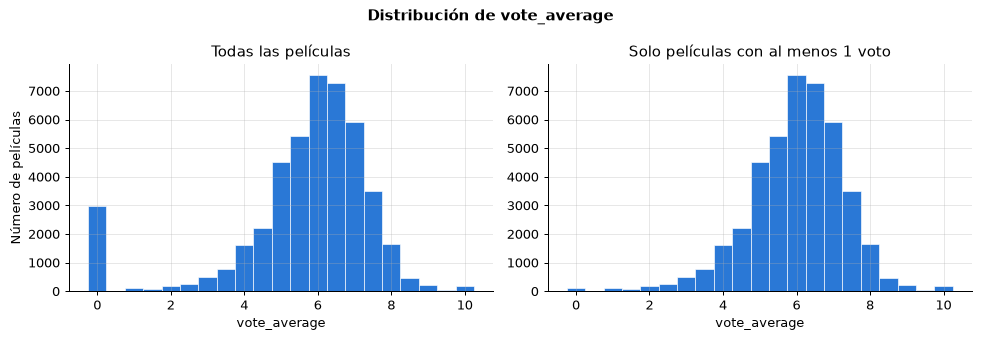

In [14]:
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=False)
bins = np.arange(-0.25, 10.26, 0.5)  # 0.5 de ancho, centrado en valores con un decimal

ejes[0].hist(df["vote_average"].dropna(), bins=bins, color=COLOR_PRINCIPAL, edgecolor="white", linewidth=0.5)
ejes[0].set_title("Todas las películas")
ejes[0].set_xlabel("vote_average")
ejes[0].set_ylabel("Número de películas")

con_votos = df.loc[df["vote_count"] > 0, "vote_average"]
ejes[1].hist(con_votos, bins=bins, color=COLOR_PRINCIPAL, edgecolor="white", linewidth=0.5)
ejes[1].set_title("Solo películas con al menos 1 voto")
ejes[1].set_xlabel("vote_average")

fig.suptitle("Distribución de vote_average", fontweight="bold")
fig.tight_layout()
plt.show()

La media de `vote_average` es 5,62 y la mediana 6,0, con desviación estándar de 1,92. El histograma de la izquierda muestra un pico aislado en 0: son 2.995 películas con `vote_average = 0`. Al quitar las películas sin votos (derecha), ese pico casi desaparece, lo que indica que la mayoría de esos ceros no son calificaciones reales sino ausencia de votos (se confirma en la sección 3.3). Sin ellas, la distribución se concentra entre 5 y 7.

### 3.3 Películas con pocos o 0 votos

`vote_average` es un promedio: si una película tiene 1 o 2 votos, su calificación depende de la opinión de una o dos personas y es muy ruidosa. Se cuantifica cuántas películas están en esa situación.

In [15]:
umbrales = [0, 1, 5, 10, 20, 50, 100]
tabla_votos = pd.DataFrame({
    "umbral": [f"vote_count <= {u}" for u in umbrales],
    "películas": [(df["vote_count"] <= u).sum() for u in umbrales],
    "porcentaje": [round((df["vote_count"] <= u).mean() * 100, 1) for u in umbrales],
})
tabla_votos

,umbral,películas,porcentaje
0,vote_count <= 0,2896,6.4
1,vote_count <= 1,6158,13.6
2,vote_count <= 5,16647,36.6
3,vote_count <= 10,23686,52.1
4,vote_count <= 20,30147,66.4
5,vote_count <= 50,36390,80.1
6,vote_count <= 100,39415,86.8


In [16]:
cero_votos = df["vote_count"] == 0
print(f"Películas con vote_count = 0: {cero_votos.sum():,}")
print(f"Películas con vote_average = 0: {(df['vote_average'] == 0).sum():,}")
print(f"  de ellas con vote_count = 0: {(cero_votos & (df['vote_average'] == 0)).sum():,}")
print(f"vote_average de las películas con 0 votos: {df.loc[cero_votos, 'vote_average'].unique()}")

Películas con vote_count = 0: 2,896
Películas con vote_average = 0: 2,995
  de ellas con vote_count = 0: 2,896
vote_average de las películas con 0 votos: [0.]


In [17]:
tramos = pd.cut(
    df["vote_count"],
    bins=[-1, 0, 5, 10, 20, 50, 100, np.inf],
    labels=["0", "1-5", "6-10", "11-20", "21-50", "51-100", ">100"],
)
resumen_tramos = df.groupby(tramos, observed=True)["vote_average"].agg(["count", "mean", "std"]).round(2)
resumen_tramos.index.name = "vote_count"
resumen_tramos

,count,mean,std
vote_count,,,
0,2896,0.00,0.00
1-5,13751,5.77,1.66
6-10,7039,5.88,1.18
11-20,6461,6.00,1.07
21-50,6243,6.13,1.00
51-100,3025,6.24,0.93
>100,6015,6.42,0.86


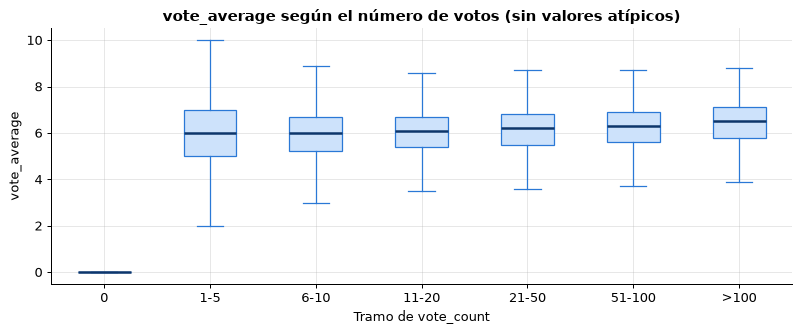

In [18]:
fig, ax = plt.subplots(figsize=(9, 3.8))
grupos = [df.loc[tramos == t, "vote_average"].dropna() for t in tramos.cat.categories]
ax.boxplot(
    grupos, tick_labels=list(tramos.cat.categories), showfliers=False,
    patch_artist=True,
    boxprops={"facecolor": "#cde2fb", "edgecolor": COLOR_PRINCIPAL},
    medianprops={"color": "#0d366b", "linewidth": 2},
    whiskerprops={"color": COLOR_PRINCIPAL}, capprops={"color": COLOR_PRINCIPAL},
)
ax.set_xlabel("Tramo de vote_count")
ax.set_ylabel("vote_average")
ax.set_title("vote_average según el número de votos (sin valores atípicos)", fontweight="bold")
fig.tight_layout()
plt.show()

Resultados:

- 2.896 películas (6,4 %) tienen 0 votos, y todas tienen `vote_average = 0`. Para ellas la variable objetivo no está definida: TMDB guarda 0 cuando nadie ha votado. Otras 99 películas tienen `vote_average = 0` con al menos 1 voto.
- El 52,1 % de las películas tiene 10 votos o menos, y el 36,6 % tiene 5 o menos.
- La dispersión de `vote_average` baja a medida que crece el número de votos: la desviación estándar pasa de 1,66 (1 a 5 votos) a 0,86 (más de 100 votos). Con pocos votos, la calificación depende de la opinión de muy pocas personas y es ruidosa.

Estos números sirven de base para decidir en la sección 4 si se filtran filas por número de votos. Filtrar filas es distinto de usar `vote_count` como predictora: `vote_count` nunca entra al modelo (fuga de información), pero sí puede usarse para decidir qué películas tienen una calificación confiable para entrenar y evaluar.

### 3.4 Ceros en `budget` (y en `revenue`)

TMDB guarda 0 cuando el presupuesto o la taquilla no se reportaron. Un 0 en estas columnas no significa "presupuesto cero" sino "dato desconocido".

In [19]:
for col in ["budget", "revenue"]:
    ceros = (df[col] == 0).sum()
    print(f"{col}: {ceros:,} ceros ({ceros / len(df):.1%}) | {(df[col] > 0).sum():,} con valor positivo")

presupuesto_pequeno = (df["budget"] > 0) & (df["budget"] < 1000)
print(f"\nbudget entre 1 y 999 dólares: {presupuesto_pequeno.sum()} películas")
df.loc[df["budget"] > 0, "budget"].describe().apply(lambda v: f"{v:,.0f}").to_frame("budget > 0")

budget: 36,550 ceros (80.5%) | 8,880 con valor positivo
revenue: 38,032 ceros (83.7%) | 7,398 con valor positivo

budget entre 1 y 999 dólares: 244 películas


,budget > 0
count,"8,880"
mean,"21,614,181"
std,"34,325,545"
min,1
25%,"2,000,000"
50%,"8,000,000"
75%,"25,000,000"
max,"380,000,000"


El 80,5 % de las películas (36.550) tiene `budget = 0`; solo 8.880 tienen presupuesto reportado. Si esos ceros se dejaran como números, el modelo interpretaría que la mayoría de películas costó 0 dólares. Por eso en la sección 4 se convierten a `NaN` antes de imputar. Además hay 244 películas con presupuesto entre 1 y 999 dólares, un valor poco creíble para un largometraje (posiblemente registrado en millones o mal capturado; no se verificó película por película). Se dejan anotadas, sin corregirlas a mano.

`revenue` tiene el mismo problema (83,7 % de ceros), pero no se usa como predictora por fuga de información (sección 4).

### 3.5 Duración (`runtime`)

In [20]:
print(f"runtime nulo: {df['runtime'].isna().sum()} ({df['runtime'].isna().mean():.2%})")
print(f"runtime = 0: {(df['runtime'] == 0).sum():,} ({(df['runtime'] == 0).mean():.2%})")
print(f"runtime > 300 minutos: {(df['runtime'] > 300).sum()}")
df["runtime"].describe().round(1).to_frame("runtime")

runtime nulo: 257 (0.57%)
runtime = 0: 1,558 (3.43%)
runtime > 300 minutos: 108


,runtime
count,45173.0
mean,94.1
std,38.4
min,0.0
25%,85.0
50%,95.0
75%,107.0
max,1256.0


`runtime` tiene 257 nulos (0,57 %) y, además, 1.558 películas (3,43 %) con duración 0, que tampoco es un valor real: igual que en `budget`, es un faltante codificado como 0. También hay 108 películas con más de 300 minutos (el máximo es 1.256), valores extremos que conviene tener en cuenta (un modelo basado en árboles es poco sensible a ellos). La mediana es 95 minutos.

### 3.6 Idioma original

In [21]:
frecuencia_idioma = df["original_language"].value_counts(normalize=True)
print(f"Idiomas distintos: {df['original_language'].nunique()}")
print(f"Idiomas con al menos 1 % de las películas: {(frecuencia_idioma >= 0.01).sum()}")
(frecuencia_idioma.head(12) * 100).round(2).to_frame("% de películas")

Idiomas distintos: 89
Idiomas con al menos 1 % de las películas: 8


,% de películas
original_language,
en,71.00
fr,5.36
it,3.37
ja,2.96
de,2.38
es,2.19
ru,1.82
hi,1.12
ko,0.98


Hay 89 idiomas originales, pero están muy desbalanceados: el inglés (`en`) concentra el 71,00 % de las películas y solo 8 idiomas superan el 1 %. Codificar los 89 idiomas crearía muchas columnas con casi ningún ejemplo, por eso los poco frecuentes se agrupan en una sola categoría. Ese 1 % se calcula aquí solo para describir los datos: la agrupación que usa el modelo la aprende el `OneHotEncoder` dentro del Pipeline, únicamente con las películas de train (sección 5).

### 3.7 Géneros

`genres` es un texto con formato de lista de diccionarios de Python, por ejemplo `"[{'id': 16, 'name': 'Animation'}, ...]"`. Para explorarlo se convierte con `ast.literal_eval`, que evalúa solo literales de Python (a diferencia de `eval`, no ejecuta código).

In [22]:
lista_generos = df["genres"].apply(lambda s: [g["name"] for g in ast.literal_eval(s)])
print(f"Películas sin ningún género: {(lista_generos.str.len() == 0).sum():,}")
print(f"Número de géneros por película: {lista_generos.str.len().value_counts().sort_index().to_dict()}")
primer_genero = lista_generos.str[0].value_counts()
primer_genero.to_frame("películas (primer género de la lista)")

Películas sin ningún género: 2,442
Número de géneros por película: {0: 2442, 1: 14552, 2: 14470, 3: 9577, 4: 3376, 5: 829, 6: 157, 7: 24, 8: 3}


,películas (primer género de la lista)
genres,
Drama,11953
Comedy,8816
Action,4486
Documentary,3413
Horror,2619
Crime,1684
Thriller,1663
Adventure,1509
Romance,1191


2.442 películas no tienen ningún género (lista vacía) y la mayoría tiene entre 1 y 3. Los géneros más frecuentes como primer elemento de la lista son Drama (11.953), Comedy (8.816) y Action (4.486). El "género principal" que se construye en la sección 4 parte de esta lista; las películas sin género necesitan una categoría propia.

### 3.8 Franquicias, fecha de estreno y otras columnas

In [23]:
print(f"Películas que pertenecen a una colección: {df['belongs_to_collection'].notna().sum():,} "
      f"({df['belongs_to_collection'].notna().mean():.1%})")

fecha = pd.to_datetime(df["release_date"], errors="coerce")
print(f"release_date no convertible a fecha: {fecha.isna().sum()} (incluye los {df['release_date'].isna().sum()} nulos)")
print(f"Rango de fechas: {fecha.min().date()} a {fecha.max().date()}")
print(f"Películas con fecha posterior a 2017: {(fecha.dt.year > 2017).sum()}")

for col in ["status", "adult", "video"]:
    print(f"\n{col}: {df[col].value_counts(dropna=False).to_dict()}")

Películas que pertenecen a una colección: 4,487 (9.9%)
release_date no convertible a fecha: 84 (incluye los 84 nulos)
Rango de fechas: 1874-12-09 a 2020-12-16
Películas con fecha posterior a 2017: 6

status: {'Released': 44985, 'Rumored': 229, 'Post Production': 98, nan: 81, 'In Production': 20, 'Planned': 15, 'Canceled': 2}

adult: {'False': 45421, 'True': 9}

video: {False: 45337, True: 93}


- Solo el 9,9 % de las películas (4.487) pertenece a una colección, lo que respalda usar `belongs_to_collection` como indicador binario `es_franquicia`.
- `release_date` tiene 84 nulos y el resto se convierte a fecha sin errores. Las fechas van de 1874 a 2020; hay 6 películas con fecha posterior a 2017. Según su descripción en Kaggle, el dataset reúne películas estrenadas hasta julio de 2017, así que esas fechas corresponden a estrenos anunciados en ese momento.
- `status`: 44.985 películas están estrenadas (`Released`) y 445 no (rumoreadas, en producción, planeadas, canceladas o sin dato).
- `adult` (9 en `True`) y `video` (93 en `True`) casi no varían, así que aportan poca información a un modelo.

### 3.9 Resumen del EDA

Hallazgos principales sobre el dataset limpio de 45.430 películas:

1. Se eliminaron 36 filas: 3 corruptas por parsing, 3 mitades incompletas de esas mismas líneas y 30 duplicados por `id`.
2. La variable objetivo `vote_average` no tiene nulos, pero 2.896 películas (6,4 %) tienen 0 votos y por eso una calificación de 0 que no es real. El 52,1 % tiene 10 votos o menos, y la calificación es más ruidosa cuanto menos votos hay.
3. `budget` tiene 80,5 % de ceros y `runtime` 3,43 % de ceros, que son faltantes codificados como 0. `runtime` tiene además 0,57 % de nulos reales, lo que cumple el requisito de la guía.
4. `original_language` está muy desbalanceado (71 % en inglés, 89 idiomas).
5. `genres` y `belongs_to_collection` requieren parseo o transformación antes de usarse.

Puntos que se deciden y justifican en las secciones 4 y 5 (preparación de variables y Pipeline):

- Qué hacer con las películas con 0 o pocos votos (filtrado de filas por `vote_count`).
- Cómo tratar los ceros de `budget` y `runtime`.
- Cómo definir el género principal y cuántos idiomas conservar.
- Si se conservan las películas que no están en estado `Released`.

## 4. Preparación de variables y fuga de información

Esta sección hace solo transformaciones **fila por fila**, que no dependen de estadísticas calculadas sobre el conjunto de datos (medias, medianas, frecuencias). Por eso se pueden hacer antes de dividir en train y test sin filtrar información. Todo lo que sí aprende de los datos (imputación, escalado, codificación de categorías) se hace en la sección 5, dentro de un Pipeline ajustado solo con train.

### 4.1 Filtro de filas: películas estrenadas y con más de 10 votos

Se aplican dos filtros con umbrales fijos, decididos por el equipo a partir del EDA:

1. **`status == "Released"`**: la calificación de los usuarios se forma después del estreno. Una película rumoreada, planeada o en producción no tiene todavía una calificación que tenga sentido predecir.
2. **`vote_count > 10`**: el EDA (sección 3.3) mostró que las 2.896 películas con 0 votos tienen `vote_average = 0` sin que nadie las haya calificado, y que con pocos votos la calificación es muy ruidosa (desviación estándar de 1,66 con 1 a 5 votos frente a 1,07 con 11 a 20). Con más de 10 votos, el promedio refleja la opinión de un grupo mínimo de personas y la variable objetivo es más confiable.

**`vote_count` se usa solo para filtrar filas, nunca como predictora.** Filtrar define la población sobre la que se entrena y se evalúa el modelo: películas estrenadas con más de 10 votos en TMDB. El modelo no recibe `vote_count` como entrada y, por lo tanto, sus predicciones aplican a películas de ese tipo; para una película con muy pocos votos su predicción no está validada. Además, el umbral es un valor fijo que se aplica a cada fila por separado: no se calcula ninguna estadística con los datos de test.

In [24]:
UMBRAL_VOTOS = 10

filas_inicio = len(df)
estrenadas = df["status"] == "Released"
con_votos_suficientes = df["vote_count"] > UMBRAL_VOTOS

print(f"Películas en el dataset limpio: {filas_inicio:,}")
print(f"  no estrenadas (status distinto de Released o nulo): {(~estrenadas).sum():,}")
print(f"  estrenadas con {UMBRAL_VOTOS} votos o menos: {(estrenadas & ~con_votos_suficientes).sum():,}")

df_modelo = df[estrenadas & con_votos_suficientes].copy()
print(f"Películas que quedan para el modelo: {len(df_modelo):,} ({len(df_modelo) / filas_inicio:.1%} del dataset limpio)")

Películas en el dataset limpio: 45,430
  no estrenadas (status distinto de Released o nulo): 445
  estrenadas con 10 votos o menos: 23,329
Películas que quedan para el modelo: 21,656 (47.7% del dataset limpio)


Se descartan 445 películas no estrenadas y 23.329 estrenadas con 10 votos o menos. Quedan **21.656 películas** (47,7 % del dataset limpio), muy por encima del mínimo de 1.000 observaciones de la guía. Después del filtro, `vote_average` tiene media 6,19 y desviación estándar 0,99 (ver la celda final de la sección 4), en lugar de 5,62 y 1,92 del dataset completo: desaparecen los ceros artificiales y las calificaciones más ruidosas.

### 4.2 Construcción de las predictoras

| Predictora | Origen | Transformación |
|---|---|---|
| `budget` | `budget` | 0 se convierte en `NaN` (presupuesto no reportado) |
| `runtime` | `runtime` | 0 se convierte en `NaN` (duración no reportada) |
| `release_year` | `release_date` | año de la fecha de estreno |
| `es_franquicia` | `belongs_to_collection` | 1 si la película pertenece a una colección, 0 si no |
| `genero_principal` | `genres` | primer género de la lista; `sin_genero` si la lista está vacía |
| `original_language` | `original_language` | sin cambios aquí; los idiomas poco frecuentes se agrupan en el Pipeline |

**Supuesto sobre el género principal.** TMDB no documenta que el primer género de la lista sea el principal de la película; el equipo lo asume como una aproximación simple para reducir la lista de géneros a una sola categoría. Es un supuesto de modelado, no un dato garantizado, y no se verificó película por película.

In [25]:
def primer_genero_o_sin_genero(texto_genres):
    """Devuelve el primer género de la lista de TMDB o 'sin_genero' si está vacía."""
    generos = ast.literal_eval(texto_genres)
    return generos[0]["name"] if generos else "sin_genero"


df_modelo["budget"] = df_modelo["budget"].replace(0, np.nan)
df_modelo["runtime"] = df_modelo["runtime"].replace(0, np.nan)
df_modelo["release_year"] = pd.to_datetime(df_modelo["release_date"], errors="coerce").dt.year
df_modelo["es_franquicia"] = df_modelo["belongs_to_collection"].notna().astype(int)
df_modelo["genero_principal"] = df_modelo["genres"].apply(primer_genero_o_sin_genero)

COLUMNAS_NUMERICAS = ["budget", "runtime", "release_year"]
COLUMNAS_BINARIAS = ["es_franquicia"]
COLUMNAS_CATEGORICAS = ["genero_principal", "original_language"]
PREDICTORAS = COLUMNAS_NUMERICAS + COLUMNAS_BINARIAS + COLUMNAS_CATEGORICAS
OBJETIVO = "vote_average"

df_modelo[PREDICTORAS + [OBJETIVO]].head()

,budget,runtime,release_year,es_franquicia,genero_principal,original_language,vote_average
0,30000000.0,81.0,1995.0,1,Animation,en,7.7
1,65000000.0,104.0,1995.0,0,Adventure,en,6.9
2,NaN,101.0,1995.0,1,Romance,en,6.5
3,16000000.0,127.0,1995.0,0,Comedy,en,6.1
4,NaN,106.0,1995.0,1,Comedy,en,5.7


### 4.3 Faltantes en las predictoras finales

In [26]:
faltantes = pd.DataFrame({
    "faltantes": df_modelo[PREDICTORAS].isna().sum(),
    "porcentaje": (df_modelo[PREDICTORAS].isna().mean() * 100).round(2),
})
faltantes

,faltantes,porcentaje
budget,14207,65.60
runtime,208,0.96
release_year,3,0.01
es_franquicia,0,0.00
genero_principal,0,0.00
original_language,1,0.00


**Sobre el requisito de faltantes de la guía (0,1 % a 2 %).** El requisito se cumple en el dataset original: `runtime` tiene 0,57 % de nulos reales (257 de 45.430 películas, sección 3.1). En las predictoras finales el porcentaje de `runtime` es 0,96 % porque, además de los nulos originales, los valores 0 se convirtieron a `NaN` y el filtro de filas cambió el total de películas. El mismo efecto explica el 65,60 % de `budget`: casi todo corresponde a presupuestos no reportados que venían como 0.

Ninguno de estos faltantes se rellena aquí. La imputación se hace dentro del Pipeline (sección 5), con valores aprendidos solo de train.

### 4.4 Columnas excluidas y fuga de información

La fuga de información (*data leakage*) ocurre cuando el modelo usa, al entrenar, información que no estaría disponible en el momento real de hacer la predicción. El modelo luce muy bien en la evaluación pero falla en uso real. La regla del equipo es usar solo características conocidas **antes o al momento del estreno**. Por eso se excluyen como predictoras:

- **`vote_count`**: sale del mismo proceso de votación que produce `vote_average`; ninguna de las dos existe antes del estreno. Se usa solo para filtrar filas (sección 4.1).
- **`popularity`**: puntaje dinámico de TMDB que se actualiza con la reacción del público después del estreno.
- **`revenue`**: la taquilla solo se conoce después de que el público vio la película. Además tiene 83,7 % de ceros.

También se excluyen, por otras razones:

- Identificadores y URL (`id`, `imdb_id`, `title`, `original_title`, `homepage`, `poster_path`): no describen la película.
- Texto libre (`overview`, `tagline`): requeriría procesamiento de lenguaje natural, fuera del alcance de esta fase.
- `adult` y `video`: casi no varían (sección 3.8).
- `production_companies`, `production_countries`, `spoken_languages`: listas con muchas categorías; quedan como posible mejora futura.
- `status`: después del filtro todas las películas son `Released`, así que es constante.

La otra fuente de fuga es el preprocesamiento: si la mediana para imputar, la media para escalar o las categorías frecuentes de un idioma se calcularan con todo el dataset, el conjunto de test influiría en el entrenamiento. La sección 5 lo evita dividiendo primero y ajustando todo el preprocesamiento solo con train.

In [27]:
COLUMNAS_CON_FUGA = ["vote_count", "popularity", "revenue"]
assert not set(COLUMNAS_CON_FUGA) & set(PREDICTORAS), "Una columna con fuga quedó como predictora"

X = df_modelo[PREDICTORAS]
y = df_modelo[OBJETIVO]
print(f"X: {X.shape[0]:,} filas x {X.shape[1]} predictoras -> {list(X.columns)}")
print(f"y: {OBJETIVO}, media {y.mean():.3f}, desviación estándar {y.std():.3f}")

X: 21,656 filas x 6 predictoras -> ['budget', 'runtime', 'release_year', 'es_franquicia', 'genero_principal', 'original_language']
y: vote_average, media 6.188, desviación estándar 0.987


## 5. División train/test y Pipeline de preprocesamiento

### 5.1 División train/test (antes de cualquier preprocesamiento)

El split se hace **antes** de imputar, escalar o codificar. A partir de aquí, el conjunto de test se trata como datos nuevos: no se mira para tomar decisiones ni se usa para ajustar nada. Se reserva el 20 % para test con una semilla fija, para que la división sea reproducible.

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEMILLA
)
print(f"Train: {X_train.shape[0]:,} películas | Test: {X_test.shape[0]:,} películas")
print(f"vote_average medio: train {y_train.mean():.3f} | test {y_test.mean():.3f}")

Train: 17,324 películas | Test: 4,332 películas
vote_average medio: train 6.192 | test 6.172


### 5.2 Preprocesamiento con `ColumnTransformer`

Cada tipo de columna recibe su propio tratamiento:

- **Numéricas** (`budget`, `runtime`, `release_year`): imputación con la mediana y escalado estándar. `add_indicator=True` agrega una columna binaria por cada variable con faltantes (por ejemplo, "budget no reportado"), porque el hecho de que falte el presupuesto puede decir algo de la película. El escalado no cambia nada para modelos basados en árboles, pero deja el preprocesamiento listo para cualquier modelo.
- **Binaria** (`es_franquicia`): pasa sin cambios.
- **Categóricas** (`genero_principal`, `original_language`): imputación con la categoría más frecuente y codificación one-hot. `OneHotEncoder(min_frequency=0.01, handle_unknown="infrequent_if_exist")` agrupa en una sola columna "infrecuente" las categorías que aparecen en menos del 1 % de las películas **de train**. Una categoría que aparezca por primera vez en test (o en una predicción futura) se asigna a ese mismo grupo en lugar de producir un error.

**Por qué esto evita la fuga de información.** La mediana usada para imputar, la media y desviación usadas para escalar, la moda de las categóricas y la lista de idiomas y géneros frecuentes son parámetros que se **aprenden de los datos**. Si se calcularan con el dataset completo, las películas de test influirían en cómo se transforman los datos de entrenamiento, y la evaluación sería optimista. Al ponerlos dentro de un Pipeline, `fit` los aprende solo con `X_train` y `transform` aplica esos mismos valores a `X_test`. Por la misma razón, la agrupación de idiomas poco frecuentes no se hace con el 1 % calculado sobre todo el dataset (como en el EDA), sino dentro del encoder.

In [29]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

FRECUENCIA_MINIMA = 0.01

transformador_numerico = Pipeline(steps=[
    ("imputar", SimpleImputer(strategy="median", add_indicator=True)),
    ("escalar", StandardScaler()),
])

transformador_categorico = Pipeline(steps=[
    ("imputar", SimpleImputer(strategy="most_frequent")),
    ("codificar", OneHotEncoder(
        min_frequency=FRECUENCIA_MINIMA,
        handle_unknown="infrequent_if_exist",
        sparse_output=False,
    )),
])

preprocesamiento = ColumnTransformer(transformers=[
    ("numericas", transformador_numerico, COLUMNAS_NUMERICAS),
    ("binarias", "passthrough", COLUMNAS_BINARIAS),
    ("categoricas", transformador_categorico, COLUMNAS_CATEGORICAS),
])
print(preprocesamiento)

ColumnTransformer(transformers=[('numericas',
                                 Pipeline(steps=[('imputar',
                                                  SimpleImputer(add_indicator=True,
                                                                strategy='median')),
                                                 ('escalar',
                                                  StandardScaler())]),
                                 ['budget', 'runtime', 'release_year']),
                                ('binarias', 'passthrough', ['es_franquicia']),
                                ('categoricas',
                                 Pipeline(steps=[('imputar',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('codificar',
                                                  OneHotEncoder(handle_unknown='infrequent_if_exist',
                                                                min_frequ

### 5.3 Comprobación: el preprocesamiento se ajusta solo con train

Para verificar qué aprende el preprocesamiento, se ajusta una copia con `X_train` y se inspeccionan sus parámetros. En la sección 6 el mismo `preprocesamiento` se usa como primer paso del Pipeline de cada modelo, que vuelve a ajustarlo con `X_train` al entrenar.

In [30]:
from sklearn.base import clone

preprocesamiento_train = clone(preprocesamiento).fit(X_train)
X_train_transformado = preprocesamiento_train.transform(X_train)
X_test_transformado = preprocesamiento_train.transform(X_test)

print(f"Columnas después del preprocesamiento: {X_train_transformado.shape[1]}")
print(f"Train transformado: {X_train_transformado.shape} | Test transformado: {X_test_transformado.shape}")
print(f"Nulos después de transformar: train {np.isnan(X_train_transformado).sum()} | test {np.isnan(X_test_transformado).sum()}")

Columnas después del preprocesamiento: 32
Train transformado: (17324, 32) | Test transformado: (4332, 32)
Nulos después de transformar: train 0 | test 0


In [31]:
imputador_num = preprocesamiento_train.named_transformers_["numericas"].named_steps["imputar"]
print("Medianas aprendidas con train:")
for columna, mediana in zip(COLUMNAS_NUMERICAS, imputador_num.statistics_):
    print(f"  {columna}: {mediana:,.1f}")

# Las medianas coinciden con las de X_train, no con las de todo X
medianas_train = X_train[COLUMNAS_NUMERICAS].median().to_numpy()
assert np.allclose(imputador_num.statistics_, medianas_train)

codificador = preprocesamiento_train.named_transformers_["categoricas"].named_steps["codificar"]
for columna, frecuentes, infrecuentes in zip(
    COLUMNAS_CATEGORICAS, codificador.categories_, codificador.infrequent_categories_
):
    n_infrecuentes = 0 if infrecuentes is None else len(infrecuentes)
    print(f"\n{columna}: {len(frecuentes) - n_infrecuentes} categorías frecuentes en train, "
          f"{n_infrecuentes} agrupadas como infrecuentes")
    print("  frecuentes:", [c for c in frecuentes if infrecuentes is None or c not in infrecuentes])

Medianas aprendidas con train:


  budget: 12,000,000.0
  runtime: 98.0
  release_year: 2,004.0

genero_principal: 14 categorías frecuentes en train, 7 agrupadas como infrecuentes
  frecuentes: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Horror', 'Mystery', 'Romance', 'Science Fiction', 'Thriller']

original_language: 9 categorías frecuentes en train, 51 agrupadas como infrecuentes
  frecuentes: ['de', 'en', 'es', 'fr', 'hi', 'it', 'ja', 'ko', 'ru']


In [32]:
pd.Series(preprocesamiento_train.get_feature_names_out(), name="columnas del modelo").to_frame()

,columnas del modelo
0,numericas__budget
1,numericas__runtime
2,numericas__release_year
3,numericas__missingindicator_budget
4,numericas__missingindicator_runtime
5,numericas__missingindicator_release_year
6,binarias__es_franquicia
7,categoricas__genero_principal_Action
8,categoricas__genero_principal_Adventure
9,categoricas__genero_principal_Animation


Resultado del preprocesamiento ajustado con train:

- Las medianas usadas para imputar (presupuesto de 12.000.000, duración de 98 minutos y año 2004) salen de las 17.324 películas de train. La aserción de la celda anterior confirma que coinciden con las medianas de `X_train` y no con las del dataset completo.
- El encoder aprendió de train que 9 idiomas y 14 géneros superan el 1 % de las películas; los 51 idiomas y 7 géneros restantes quedan agrupados en una columna `infrequent_sklearn` por variable. Estas listas se aprendieron solo con train: un idioma que solo aparezca en test cae en la columna infrecuente, sin error.
- Las 6 predictoras se convierten en 32 columnas numéricas sin nulos, tanto en train como en test: 3 numéricas escaladas, 3 indicadores de faltante, `es_franquicia`, 15 columnas de género y 10 de idioma.

El objeto `preprocesamiento` (sin ajustar) es el que se reutiliza como primer paso del Pipeline de cada modelo en la sección 6.

## 6. Modelos y evaluación

### 6.1 Modelos comparados

Se comparan tres modelos. Cada uno es un Pipeline completo: primero el mismo `preprocesamiento` de la sección 5 y después el regresor. Así, al llamar `fit(X_train, y_train)`, el preprocesamiento se ajusta con train dentro del propio Pipeline.

- **Baseline (`DummyRegressor`)**: predice siempre la media de `vote_average` en train. Cualquier modelo útil debe superarlo.
- **`Ridge`**: regresión lineal con regularización. Es un modelo simple que sirve de referencia intermedia.
- **`HistGradientBoostingRegressor`**: ensamble de árboles de decisión construidos en secuencia. Captura relaciones no lineales e interacciones (por ejemplo, entre género y año).

Se usan los hiperparámetros por defecto, con semilla fija. El objetivo del curso es un modelo correcto y reproducible, no el mejor posible, así que no se hace búsqueda de hiperparámetros.

In [33]:
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import KFold, cross_validate


def crear_pipeline(regresor):
    """Pipeline completo: preprocesamiento (sin ajustar) + regresor."""
    return Pipeline(steps=[
        ("preprocesamiento", clone(preprocesamiento)),
        ("modelo", regresor),
    ])


modelos = {
    "Baseline (media)": crear_pipeline(DummyRegressor(strategy="mean")),
    "Ridge": crear_pipeline(Ridge(alpha=1.0)),
    "HistGradientBoosting": crear_pipeline(HistGradientBoostingRegressor(random_state=SEMILLA)),
}

### 6.2 Selección del modelo con validación cruzada sobre train

Para elegir el modelo no se usa el conjunto de test: si se eligiera el que mejor le va en test, test dejaría de ser una estimación honesta del desempeño con datos nuevos. En su lugar se hace validación cruzada de 5 particiones **solo con train**: en cada partición, el Pipeline completo (preprocesamiento incluido) se ajusta con 4/5 de train y se evalúa en el 1/5 restante.

Métricas (todas en la escala de `vote_average`, de 0 a 10):

- **MAE** (error absoluto medio): en promedio, cuántos puntos se equivoca la predicción. Fácil de interpretar.
- **RMSE** (raíz del error cuadrático medio): como el MAE, pero penaliza más los errores grandes.
- **R²**: proporción de la varianza de `vote_average` que explica el modelo. 0 equivale al baseline; 1 sería una predicción perfecta.

In [34]:
validacion = KFold(n_splits=5, shuffle=True, random_state=SEMILLA)
metricas_cv = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

filas_cv = []
for nombre, pipeline in modelos.items():
    resultado = cross_validate(pipeline, X_train, y_train, cv=validacion, scoring=metricas_cv)
    filas_cv.append({
        "modelo": nombre,
        "MAE": -resultado["test_MAE"].mean(),
        "RMSE": -resultado["test_RMSE"].mean(),
        "RMSE (desv. entre folds)": resultado["test_RMSE"].std(),
        "R2": resultado["test_R2"].mean(),
    })

resultados_cv = pd.DataFrame(filas_cv).set_index("modelo").round(4)
resultados_cv

,MAE,RMSE,RMSE (desv. entre folds),R2
modelo,,,,
Baseline (media),0.7771,0.9865,0.0058,-0.0002
Ridge,0.6631,0.8592,0.0093,0.2412
HistGradientBoosting,0.6170,0.7989,0.0072,0.3440


In [35]:
MEJOR_MODELO = resultados_cv["RMSE"].idxmin()
print(f"Modelo seleccionado por menor RMSE en validación cruzada: {MEJOR_MODELO}")

Modelo seleccionado por menor RMSE en validación cruzada: HistGradientBoosting


### 6.3 Evaluación final en test

Cada Pipeline se entrena con todo train y se evalúa una sola vez en test, que no se usó en ninguna decisión anterior.

In [36]:
filas_test = []
predicciones_test = {}
for nombre, pipeline in modelos.items():
    pipeline.fit(X_train, y_train)
    prediccion = pipeline.predict(X_test)
    predicciones_test[nombre] = prediccion
    filas_test.append({
        "modelo": nombre,
        "MAE": mean_absolute_error(y_test, prediccion),
        "RMSE": root_mean_squared_error(y_test, prediccion),
        "R2": r2_score(y_test, prediccion),
    })

resultados_test = pd.DataFrame(filas_test).set_index("modelo").round(4)
resultados_test

,MAE,RMSE,R2
modelo,,,
Baseline (media),0.7823,0.9880,-0.0004
Ridge,0.6578,0.8499,0.2598
HistGradientBoosting,0.6059,0.7813,0.3745


In [37]:
base = resultados_test.loc["Baseline (media)"]
mejor = resultados_test.loc[MEJOR_MODELO]
print(f"{MEJOR_MODELO} frente al baseline en test:")
print(f"  MAE:  {base['MAE']:.3f} -> {mejor['MAE']:.3f} ({(base['MAE'] - mejor['MAE']) / base['MAE']:.1%} menos error)")
print(f"  RMSE: {base['RMSE']:.3f} -> {mejor['RMSE']:.3f} ({(base['RMSE'] - mejor['RMSE']) / base['RMSE']:.1%} menos error)")
print(f"  R2:   {base['R2']:.3f} -> {mejor['R2']:.3f}")

HistGradientBoosting frente al baseline en test:
  MAE:  0.782 -> 0.606 (22.5% menos error)
  RMSE: 0.988 -> 0.781 (20.9% menos error)
  R2:   -0.000 -> 0.374


**Lectura de los resultados.**

- El baseline tiene R² ≈ 0 por construcción (predice siempre la media) y un RMSE de 0,988, prácticamente igual a la desviación estándar de `vote_average` en esta población (0,99). Es el punto de referencia.
- Los dos modelos reales superan al baseline en las tres métricas, tanto en validación cruzada como en test. HistGradientBoosting es el mejor: en test su MAE es 0,606 (se equivoca en promedio 0,6 puntos en una escala de 0 a 10), su RMSE 0,781 y su R² 0,374, frente a 0,260 de Ridge. La diferencia con Ridge indica que hay relaciones no lineales que un modelo lineal no captura.
- Las métricas de test (RMSE 0,781) son coherentes con las de validación cruzada (0,799, con desviación de 0,007 entre particiones): no hay señales de sobreajuste ni de que el resultado en test sea casualidad de la partición.
- Un R² de 0,374 significa que las 6 predictoras disponibles antes del estreno explican alrededor de un tercio de la variación de la calificación. Es un resultado razonable: la calificación depende mucho de factores que no están en estas variables (guion, dirección, actuaciones, recepción crítica).

### 6.4 Predicción frente a valor real

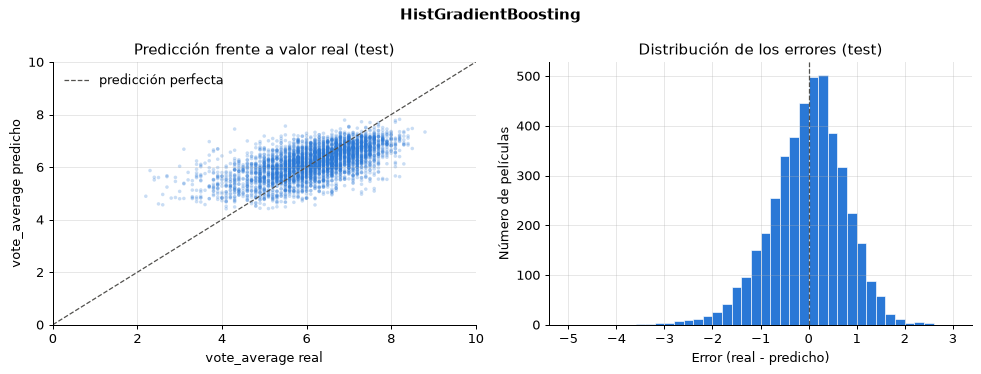

Películas de test con error absoluto menor a 0,5 puntos: 50.3%
Películas de test con error absoluto menor a 1 punto: 81.4%
Rango de vote_average real en test: 2.2 a 8.8
Rango de las predicciones en test: 4.41 a 7.82
Error medio (real - predicho) para películas con vote_average real < 5: -1.21
Error medio (real - predicho) para películas con vote_average real >= 7.5: 0.98


In [38]:
prediccion_mejor = predicciones_test[MEJOR_MODELO]

fig, ejes = plt.subplots(1, 2, figsize=(11, 4.2))
ejes[0].scatter(y_test, prediccion_mejor, s=8, alpha=0.25, color=COLOR_PRINCIPAL, edgecolors="none")
ejes[0].plot([0, 10], [0, 10], color="#52514e", linewidth=1, linestyle="--", label="predicción perfecta")
ejes[0].set_xlim(0, 10)
ejes[0].set_ylim(0, 10)
ejes[0].set_xlabel("vote_average real")
ejes[0].set_ylabel("vote_average predicho")
ejes[0].set_title("Predicción frente a valor real (test)")
ejes[0].legend(loc="upper left", frameon=False)

residuos = y_test - prediccion_mejor
ejes[1].hist(residuos, bins=np.arange(-5, 3.01, 0.2), color=COLOR_PRINCIPAL, edgecolor="white", linewidth=0.5)
ejes[1].axvline(0, color="#52514e", linewidth=1, linestyle="--")
ejes[1].set_xlabel("Error (real - predicho)")
ejes[1].set_ylabel("Número de películas")
ejes[1].set_title("Distribución de los errores (test)")

fig.suptitle(MEJOR_MODELO, fontweight="bold")
fig.tight_layout()
plt.show()

error_absoluto = np.abs(residuos)
print(f"Películas de test con error absoluto menor a 0,5 puntos: {(error_absoluto < 0.5).mean():.1%}")
print(f"Películas de test con error absoluto menor a 1 punto: {(error_absoluto < 1).mean():.1%}")
print(f"Rango de vote_average real en test: {y_test.min():.1f} a {y_test.max():.1f}")
print(f"Rango de las predicciones en test: {prediccion_mejor.min():.2f} a {prediccion_mejor.max():.2f}")
print(f"Error medio (real - predicho) para películas con vote_average real < 5: {residuos[y_test < 5].mean():.2f}")
print(f"Error medio (real - predicho) para películas con vote_average real >= 7.5: {residuos[y_test >= 7.5].mean():.2f}")

El 81,4 % de las películas de test tiene un error menor a 1 punto y la mitad (50,3 %) menor a 0,5. La distribución de los errores está centrada en 0.

El gráfico de la izquierda muestra una limitación: las predicciones se concentran entre 4,41 y 7,82, mientras que las calificaciones reales van de 2,2 a 8,8. El modelo sobreestima las películas peor calificadas (para las que tienen menos de 5, el error medio es −1,21: predice más de lo real) y subestima las mejor calificadas (+0,98 para las de 7,5 o más). Es el comportamiento esperado de un modelo con poder explicativo moderado: cuando las predictoras no alcanzan a distinguir los casos extremos, las predicciones se acercan a la media.

### 6.5 Importancia de las predictoras

La importancia por permutación mide cuánto empeora el modelo (aquí, cuánto aumenta el RMSE en test) cuando se desordenan al azar los valores de una predictora. Si el error sube mucho, el modelo depende de esa variable. Se aplica sobre las 6 predictoras originales, porque el Pipeline recibe `X` sin transformar.

In [39]:
from sklearn.inspection import permutation_importance

importancia = permutation_importance(
    modelos[MEJOR_MODELO], X_test, y_test,
    scoring="neg_root_mean_squared_error", n_repeats=5, random_state=SEMILLA,
)
tabla_importancia = pd.DataFrame({
    "aumento del RMSE": importancia.importances_mean,
    "desv. estándar": importancia.importances_std,
}, index=X_test.columns).sort_values("aumento del RMSE", ascending=False).round(4)
tabla_importancia

,aumento del RMSE,desv. estándar
runtime,0.1344,0.0032
genero_principal,0.1205,0.0063
release_year,0.0998,0.0047
original_language,0.0662,0.0043
budget,0.0207,0.0015
es_franquicia,0.0087,0.0002


Las predictoras que más usa el modelo son `runtime` (desordenarla aumenta el RMSE en 0,134), `genero_principal` (0,121) y `release_year` (0,100), seguidas de `original_language` (0,066). `budget` (0,021) y `es_franquicia` (0,009) aportan poco. En el caso de `budget`, es coherente con que el 65,6 % de sus valores falta y se imputa.

Esta importancia describe en qué se apoya el modelo para predecir, no relaciones de causa y efecto: por ejemplo, que `runtime` sea importante no significa que alargar una película mejore su calificación.

## 7. Guardado del modelo

Se guarda con joblib el **Pipeline completo** del modelo seleccionado (preprocesamiento + regresor), entrenado con train. Guardar el Pipeline y no solo el regresor es importante: quien cargue el archivo puede pasarle un DataFrame con las 6 predictoras en su forma original (con `NaN` donde falten datos) y el Pipeline aplica la misma imputación, escalado y codificación aprendidos en train.

Junto al modelo se guarda un archivo JSON con los metadatos necesarios para reutilizarlo y compararlo en fases posteriores: predictoras, filtros aplicados, métricas en test y versiones de las librerías.

In [40]:
import json
import platform

import joblib
import sklearn

CARPETA_MODELOS = RAIZ / "fase-1" / "models"
CARPETA_MODELOS.mkdir(parents=True, exist_ok=True)
RUTA_MODELO = CARPETA_MODELOS / "modelo_vote_average.joblib"
RUTA_METADATOS = CARPETA_MODELOS / "modelo_vote_average.json"

modelo_final = modelos[MEJOR_MODELO]
joblib.dump(modelo_final, RUTA_MODELO)

metadatos = {
    "modelo": MEJOR_MODELO,
    "objetivo": OBJETIVO,
    "predictoras": {
        "numericas": COLUMNAS_NUMERICAS,
        "binarias": COLUMNAS_BINARIAS,
        "categoricas": COLUMNAS_CATEGORICAS,
    },
    "poblacion": {
        "status": "Released",
        "vote_count_minimo_exclusivo": UMBRAL_VOTOS,
        "nota": "vote_count se usa solo para filtrar filas, no es predictora",
    },
    "columnas_excluidas_por_fuga": COLUMNAS_CON_FUGA,
    "division": {"test_size": 0.2, "random_state": SEMILLA,
                 "n_train": int(len(X_train)), "n_test": int(len(X_test))},
    "metricas_test": {m: float(resultados_test.loc[MEJOR_MODELO, m]) for m in ["MAE", "RMSE", "R2"]},
    "metricas_test_baseline": {m: float(resultados_test.loc["Baseline (media)", m]) for m in ["MAE", "RMSE", "R2"]},
    "versiones": {
        "python": platform.python_version(),
        "scikit-learn": sklearn.__version__,
        "pandas": pd.__version__,
        "numpy": np.__version__,
        "joblib": joblib.__version__,
    },
}
with open(RUTA_METADATOS, "w", encoding="utf-8", newline="\n") as archivo:
    json.dump(metadatos, archivo, ensure_ascii=False, indent=2)
    archivo.write("\n")

print(f"Modelo guardado en: {RUTA_MODELO.relative_to(RAIZ).as_posix()} ({RUTA_MODELO.stat().st_size / 1024:.0f} KB)")
print(f"Metadatos guardados en: {RUTA_METADATOS.relative_to(RAIZ).as_posix()}")

Modelo guardado en: fase-1/models/modelo_vote_average.joblib (368 KB)
Metadatos guardados en: fase-1/models/modelo_vote_average.json


### 7.1 Comprobación: cargar el modelo y predecir

Se carga el archivo desde disco y se verifica que produce exactamente las mismas predicciones sobre test que el modelo en memoria.

In [41]:
modelo_cargado = joblib.load(RUTA_MODELO)
prediccion_cargado = modelo_cargado.predict(X_test)
assert np.allclose(prediccion_cargado, predicciones_test[MEJOR_MODELO])
print(f"El modelo cargado reproduce las predicciones de test. RMSE: {root_mean_squared_error(y_test, prediccion_cargado):.4f}")

El modelo cargado reproduce las predicciones de test. RMSE: 0.7813


Ejemplo de uso con películas nuevas. Los valores son ilustrativos (no son películas reales del dataset); se incluye un idioma que no aparece en train (`"xx"`) y un presupuesto desconocido para mostrar que el Pipeline los maneja sin error.

In [42]:
peliculas_nuevas = pd.DataFrame([
    {"budget": 150_000_000, "runtime": 130, "release_year": 2016, "es_franquicia": 1,
     "genero_principal": "Action", "original_language": "en"},
    {"budget": np.nan, "runtime": 95, "release_year": 2010, "es_franquicia": 0,
     "genero_principal": "Drama", "original_language": "fr"},
    {"budget": 2_000_000, "runtime": 88, "release_year": 2015, "es_franquicia": 0,
     "genero_principal": "Horror", "original_language": "xx"},
])
peliculas_nuevas["vote_average_predicho"] = modelo_cargado.predict(peliculas_nuevas[PREDICTORAS]).round(2)
peliculas_nuevas

,budget,runtime,release_year,es_franquicia,genero_principal,original_language,vote_average_predicho
0,150000000.0,130,2016,1,Action,en,6.45
1,NaN,95,2010,0,Drama,fr,6.26
2,2000000.0,88,2015,0,Horror,xx,5.24


## 8. Conclusiones y limitaciones

**Qué se hizo.** Se limpió `movies_metadata.csv` (36 filas eliminadas por errores de parsing y duplicados), se exploraron los datos con cifras reales, se restringió la población a películas estrenadas con más de 10 votos (21.656 películas) y se construyeron 6 predictoras conocidas antes o al momento del estreno. Se evitó la fuga de información excluyendo `vote_count`, `popularity` y `revenue`, haciendo el split antes de cualquier preprocesamiento y ajustando imputación, escalado y codificación dentro de un Pipeline solo con train. El modelo se eligió con validación cruzada sobre train y se evaluó una sola vez en test.

**Resultado.** El Pipeline con HistGradientBoosting obtiene en test MAE 0,606, RMSE 0,781 y R² 0,374, frente a MAE 0,782, RMSE 0,988 y R² ≈ 0 del baseline: reduce el error en un 21 % a 23 %. Está guardado en `fase-1/models/modelo_vote_average.joblib`, con sus metadatos en `modelo_vote_average.json`.

**Limitaciones.**

- El modelo explica alrededor de un tercio de la variación de la calificación y comprime las predicciones hacia la media: sobreestima las películas malas y subestima las muy buenas.
- Solo aplica a películas estrenadas con más de 10 votos en TMDB; para películas con menos votos sus predicciones no están validadas.
- El género principal se toma como el primero de la lista de TMDB, un supuesto que no está garantizado.
- `budget` falta en el 65,6 % de las películas del modelo y se imputa con la mediana de train.
- Se usaron hiperparámetros por defecto, sin búsqueda, porque el objetivo de esta fase es un modelo correcto y reproducible.
- El modelo guardado se entrenó solo con train (80 % de los datos), para que las métricas reportadas correspondan exactamente al archivo guardado.